# Lesson 14: Test Selection and End-to-End Capstone

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Use outcome type, design, estimand, and assumptions to select a test
2. Complete a reproducible analysis from question through communication
3. Audit a result for common validity threats
4. Write a concise statistical results paragraph


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 14.1 Decision sequence

1. **Question:** What decision will the analysis support?
2. **Estimand:** Mean difference, risk difference, odds ratio, rank contrast, correlation, or survival contrast?
3. **Outcome:** Quantitative, ordinal, categorical, count, or time-to-event?
4. **Design:** One sample, independent groups, paired/repeated, clustered, randomized, or observational?
5. **Diagnostics:** Independence, shape/outliers, variance pattern, expected counts, censoring mechanism?
6. **Inference:** Estimate + CI + effect size + test, with multiplicity handling.
7. **Communication:** Practical meaning, uncertainty, limitations, and next action.


## 14.2 Capstone scenario

The capstone uses the balanced RAND Health Insurance Experiment teaching sample. The primary outcome is the number of
physician visits; the secondary outcome is whether any visit occurred. We compare individual-deductible and other plans,
bootstrap the mean visit difference, test the binary rate difference, and apply Holm adjustment across the two claims.


In [2]:
rand = pd.read_csv(DATA_DIR / "rand_hie_teaching_sample.csv")
other = rand.loc[rand["plan_group"] == "Other plan", "physician_visits"].to_numpy()
deductible = rand.loc[rand["plan_group"] == "Individual deductible", "physician_visits"].to_numpy()

visit_test = stats.ttest_ind(deductible, other, equal_var=False)
observed_visit_diff = deductible.mean()-other.mean()
boot = np.empty(5000)
for i in range(len(boot)):
    boot[i] = (rng.choice(deductible, len(deductible), replace=True).mean()
               - rng.choice(other, len(other), replace=True).mean())
visit_ci = np.quantile(boot, [.025, .975])

from statsmodels.stats.proportion import proportions_ztest
summary = rand.groupby("plan_group")["any_physician_visit"].agg(["sum", "count"])
successes = np.array([summary.loc["Individual deductible", "sum"], summary.loc["Other plan", "sum"]])
totals = np.array([summary.loc["Individual deductible", "count"], summary.loc["Other plan", "count"]])
z, any_visit_p = proportions_ztest(successes, totals)

from statsmodels.stats.multitest import multipletests
raw_ps = [visit_test.pvalue, any_visit_p]
holm_ps = multipletests(raw_ps, method="holm")[1]
capstone = pd.DataFrame({
    "outcome": ["Number of physician visits", "Any physician visit"],
    "estimate": [observed_visit_diff, successes[0]/totals[0]-successes[1]/totals[1]],
    "raw p": raw_ps, "Holm p": holm_ps,
    "units": ["visits (deductible-other)", "proportion points (deductible-other)"]})
capstone


,outcome,estimate,raw p,Holm p,units
0,Number of physician visits,-0.3175,0.2383,0.4766,visits (deductible-other)
1,Any physician visit,-0.0250,0.4563,0.4766,proportion points (deductible-other)


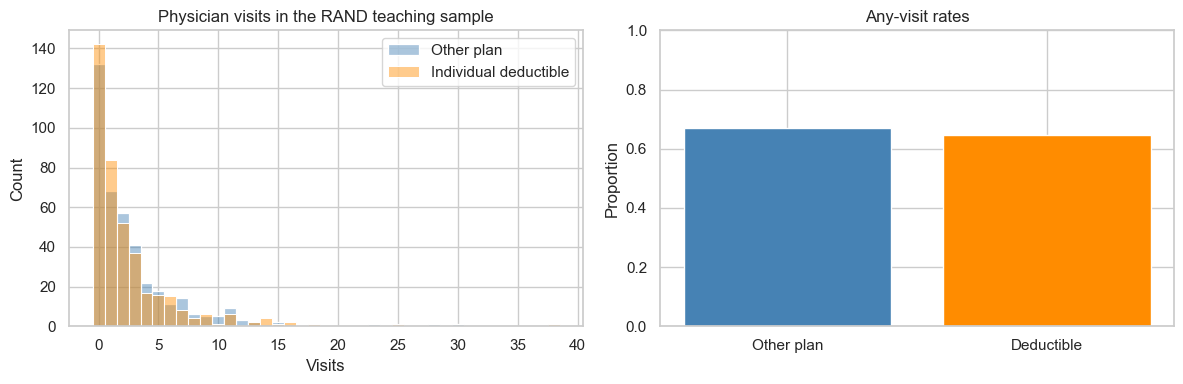

Visit difference 95% bootstrap CI: [-0.85, 0.21]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(other, discrete=True, color="steelblue", alpha=.45, label="Other plan", ax=axes[0])
sns.histplot(deductible, discrete=True, color="darkorange", alpha=.45,
             label="Individual deductible", ax=axes[0])
axes[0].set(title="Physician visits in the RAND teaching sample", xlabel="Visits")
axes[0].legend()
rates = [rand.loc[rand["plan_group"] == name, "any_physician_visit"].mean()
         for name in ["Other plan", "Individual deductible"]]
axes[1].bar(["Other plan", "Deductible"], rates, color=["steelblue", "darkorange"])
axes[1].set(title="Any-visit rates", ylabel="Proportion", ylim=(0, 1))
plt.tight_layout(); plt.show()
print(f"Visit difference 95% bootstrap CI: [{visit_ci[0]:.2f}, {visit_ci[1]:.2f}]")


## 14.3 Reporting template

> In the RAND teaching sample, the individual-deductible group differed from the other-plan group by **[estimate]**
> physician visits (95% bootstrap CI **[low, high]**; Welch **t(df)=...**, Holm-adjusted **p=...**). The any-visit rate
> differed by **[absolute percentage points]** (adjusted **p=...**). These outcomes answer related but distinct questions.
> Interpretation is limited to the documented teaching subset and should include practical thresholds and uncertainty.


## Worked example and interpretation

### Walk through both outcomes

The balanced RAND HIE teaching subset compares individual-deductible with other plans. For the number of physician visits, the observed **deductible minus other-plan** mean difference is −0.318 visits. Welch's test gives p = 0.238, and a within-group bootstrap gives a 95% percentile interval from −0.85 to +0.21 visits. The plot shows the discrete, skewed count distribution that motivates checking a count-specific model in a fuller analysis. For the secondary binary outcome, the any-visit rate difference is −0.025, with a two-proportion test p = 0.456. These outcomes capture different aspects of utilization and should not be collapsed into one claim.

### Complete the decision

The notebook applies Holm adjustment to the two displayed p-values; both adjusted values are about 0.477. The analysis therefore does not provide clear evidence of a difference on either outcome at the planned 0.05 level. That statement is narrower than saying the plans are equivalent or have no effect, because the intervals still allow changes that may matter. This is a selected teaching sample, not the full experiment; a final causal report would revisit the original assignment, outcome definitions, missingness, the count model, multiplicity plan, and decision threshold.

## Practice and solution

**Practice.** List three checks needed before treating this teaching analysis as a complete experiment report.

<details><summary>Solution</summary>

Examples include analyzing the complete RAND sample rather than only the balanced teaching subset; verifying the original
randomization and observation unit; pre-specifying the primary outcome and useful effect; assessing count-model choices,
missingness, and adherence; and documenting whether additional outcomes or subgroups were examined.
</details>

## Key takeaways

- Test selection begins with the design, outcome, and estimand.
- Real data remove arbitrary generated values but do not remove modeling assumptions.
- A complete report includes uncertainty, practical importance, provenance, and limitations.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
